In [ ]:
import torch
import sys

print('Python version:', sys.version)
print('Torch version:', torch.__version__)

# Detailed GPU Check
cuda_available = torch.cuda.is_available()
print('CUDA available:', cuda_available)

if cuda_available:
    print(f'GPU Device Name: {torch.cuda.get_device_name(0)}')
    print(f'Current Device Index: {torch.cuda.current_device()}')
else:
    print('❌ GPU NOT DETECTED. Please ensure "T4 GPU" is selected in Runtime > Change runtime type.')

Torch version: 2.10.0+cpu
CUDA available: False


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("saumyapatel/traffic-vehicles-object-detection")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'traffic-vehicles-object-detection' dataset.
Path to dataset files: /kaggle/input/traffic-vehicles-object-detection


In [ ]:
!pip install ultralytics


In [ ]:
from ultralytics import YOLO

In [ ]:
# Define dataset path
dataset_path = "/kaggle/input/traffic-vehicles-object-detection/Traffic Dataset"

# List contents to verify structure
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")



Traffic Dataset/
  labels/
    val/
    train/
  images/
    val/
    test/
    train/


In [ ]:
import os

# The root path you provided
base_path = "/kaggle/input/traffic-vehicles-object-detection/Traffic Dataset"

# Corrected sub-directories
# Most YOLO datasets on Kaggle follow this structure: base/images/train and base/labels/train
img_dir = os.path.join(base_path, "images/train")
label_dir = os.path.join(base_path, "labels/train")

# Verify existence before processing
if not os.path.exists(img_dir):
    print(f"Directory not found: {img_dir}")
    print("Checking for alternative structure...")
    # Alternative: Some datasets put them directly in 'images' and 'labels'
    img_dir = os.path.join(base_path, "images")
    label_dir = os.path.join(base_path, "labels")

if os.path.exists(img_dir):
    image_files = sorted([f[:-4] for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png', '.jpeg'))])
    label_files = sorted([f[:-4] for f in os.listdir(label_dir) if f.endswith('.txt')])

    print(f"Successfully connected!")
    print(f"Images: {len(image_files)}, Labels: {len(label_files)}")

    missing_labels = set(image_files) - set(label_files)
    if missing_labels:
        print(f"Missing labels for: {len(missing_labels)} images.")
    else:
        print("All images have labels.")
else:
    print("CRITICAL ERROR: Could not find the image folder. Run '!ls -R /kaggle/input' to see the full map.")

Successfully connected!
Images: 738, Labels: 738
All images have labels.


### preprocessing step


In [ ]:
import os

# The 'path' variable holds the base directory from kagglehub.dataset_download
# Assuming the actual dataset is in a subfolder named "Traffic Dataset"
base_dataset_dir = os.path.join(path, "Traffic Dataset")

img_dir = os.path.join(base_dataset_dir, "images", "train")
label_dir = os.path.join(base_dataset_dir, "labels", "train")

# Check if directories exist before listing
if not os.path.exists(img_dir):
    print(f"Error: Image directory not found at {img_dir}")
    raise FileNotFoundError(f"Image directory not found: {img_dir}")
if not os.path.exists(label_dir):
    print(f"Error: Label directory not found at {label_dir}")
    raise FileNotFoundError(f"Label directory not found: {label_dir}")


image_files = sorted([f[:-4] for f in os.listdir(img_dir) if f.endswith('.jpg') or f.endswith('.png')])
label_files = sorted([f[:-4] for f in os.listdir(label_dir) if f.endswith('.txt')])

print(f"Images: {len(image_files)}, Labels: {len(label_files)}")

missing_labels = set(image_files) - set(label_files)
print(f"Missing labels for: {missing_labels}")

Images: 738, Labels: 738
Missing labels for: set()


In [ ]:
import os

# The 'path' variable holds the base directory from kagglehub.dataset_download
# Assuming the actual dataset is in a subfolder named "Traffic Dataset"
base_dataset_dir = os.path.join(path, "Traffic Dataset")

yaml_content = f"""
path: {base_dataset_dir}
train: {os.path.join(base_dataset_dir, "images", "train")}
val: {os.path.join(base_dataset_dir, "images", "val")}

nc: 7
names: ['Car', 'Number Plate', 'Blur Number Plate', 'Two Wheeler', 'Auto', 'Bus', 'Truck']
"""

with open("data.yaml", "w") as f:
    f.write(yaml_content)

# Confirm it's written correctly
!cat data.yaml


path: /kaggle/input/traffic-vehicles-object-detection/Traffic Dataset
train: /kaggle/input/traffic-vehicles-object-detection/Traffic Dataset/images/train
val: /kaggle/input/traffic-vehicles-object-detection/Traffic Dataset/images/val

nc: 7
names: ['Car', 'Number Plate', 'Blur Number Plate', 'Two Wheeler', 'Auto', 'Bus', 'Truck']


In [ ]:
!find . -name "data.yaml"


./data.yaml


In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8m.pt')  # or yolov8m.pt
model.train(
    data='data.yaml',
    epochs=30,
    imgsz=640,
    project='runs/train',     # ✅ Ensures it's saved under runs/train/
    name='vehicle_yolov8',    # ✅ Makes folder runs/train/vehicle_yolov8
    exist_ok=True
)


In [ ]:
import torch
if torch.cuda.is_available():
    print(f"✅ GPU Detected: {torch.cuda.get_device_name(0)}")
else:
    print("❌ No GPU detected. Please go to Runtime > Change runtime type and select a GPU accelerator.")

In [ ]:
!ls runs/train/
!ls runs/train/*/weights/


In [ ]:
from ultralytics import YOLO

# Load the trained model
model = YOLO('runs/train/vehicle_yolov8/weights/best.pt')

# Run prediction on validation images
model.predict(
    source='/kaggle/input/traffic-vehicles-object-detection/Traffic Dataset/images/val',
    save=True,
    save_txt=True,
    conf=0.25,
    project='runs/predict',
    name='val_results',
    exist_ok=True
)


In [ ]:
import torch
import kagglehub
import os
from ultralytics import YOLO

# 1. Verify GPU
print(f"Using GPU: {torch.cuda.get_device_name(0)}" if torch.cuda.is_available() else "GPU not found.")

# 2. Re-download dataset
path = kagglehub.dataset_download("saumyapatel/traffic-vehicles-object-detection")
base_dataset_dir = os.path.join(path, "Traffic Dataset")

# 3. Re-create data.yaml with correct paths
yaml_content = f"""
path: {base_dataset_dir}
train: {os.path.join(base_dataset_dir, 'images', 'train')}
val: {os.path.join(base_dataset_dir, 'images', 'val')}

nc: 7
names: ['Car', 'Number Plate', 'Blur Number Plate', 'Two Wheeler', 'Auto', 'Bus', 'Truck']
"""
with open('data.yaml', 'w') as f:
    f.write(yaml_content)

print("Environment ready for GPU training.")

In [ ]:
model = YOLO('yolov8m.pt')
# Using device='cpu' to avoid the error, but switch to 0 if you get a GPU
results = model.train(
    data='data.yaml',
    epochs=30,
    imgsz=640,
    device='cpu'
)

In [ ]:
!kaggle kernels output abc12369/dam-crack-68 -p /path/to/dest

Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 4, in <module>
    from kaggle.cli import main
  File "/usr/local/lib/python3.12/dist-packages/kaggle/__init__.py", line 6, in <module>
    api.authenticate()
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 434, in authenticate
    raise IOError('Could not find {}. Make sure it\'s located in'
OSError: Could not find kaggle.json. Make sure it's located in /root/.kaggle. Or use the environment method. See setup instructions at https://github.com/Kaggle/kaggle-api/


In [ ]:
!ls -F /content/

sample_data/


First, create the `.kaggle` directory if it doesn't already exist. This is where Kaggle expects to find your authentication token.

In [ ]:
import os

# Create .kaggle directory if it doesn't exist
!mkdir -p ~/.kaggle

Next, move the `kaggle.json` file that you uploaded to the correct directory. Assuming you uploaded it to the current working directory (`/content/`).

In [ ]:
# Move kaggle.json to the created directory
!mv kaggle.json ~/.kaggle/

mv: cannot stat 'kaggle.json': No such file or directory


Finally, set the correct permissions for the `kaggle.json` file. This is crucial for security and for the Kaggle API to function correctly.

In [ ]:
# Set permissions for kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API key setup complete!")

chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Kaggle API key setup complete!


In [ ]:
import torch
if torch.cuda.is_available():
    print(f"✅ GPU Detected: {torch.cuda.get_device_name(0)}")
    print("You can now run the training cell.")
else:
    print("❌ GPU NOT FOUND. Please check 'Change runtime type' again.")

# ### evaluation on updated model

In [ ]:
metrics = model.val()

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (AMD EPYC 7B12)
YOLOv8m summary (fused): 92 layers, 25,886,080 parameters, 0 gradients, 78.9 GFLOPs

WARNING ⚠️ Dataset 'coco.yaml' images not found, missing path '/content/datasets/coco/val2017.txt'
Unzipping /content/datasets/coco2017labels-segments.zip to /content/datasets/coco...: 100% ━━━━━━━━━━━━ 122232/122232 5.8Kfiles/s 21.2s
Unzipping /content/datasets/coco/images/val2017.zip to /content/datasets/coco/images/val2017...: 100% ━━━━━━━━━━━━ 5001/5001 1.5Kfiles/s 3.3s
Unzipping /content/datasets/coco/images/test2017.zip to /content/datasets/coco/images/test2017...: 100% ━━━━━━━━━━━━ 40671/40671 611.0files/s 1:07
Unzipping /content/datasets/coco/images/train2017.zip to /content/datasets/coco/images/train2017...: 100% ━━━━━━━━━━━━ 118288/118288 489.5files/s 4:02
Dataset download success ✅ (1211.9s), saved to /content/datasets

val: Fast image access ✅ (ping: 0.2±0.0 ms, read: 34.6±11.7 MB/s, size: 163.3 KB)
val: Scanning /cont

In [ ]:
# Get scalar values from the metrics object
precision = metrics.box.mp
recall = metrics.box.mr
map50 = metrics.box.map50
map5095 = metrics.box.map         # mAP@0.5:0.95

# Compute F1 Score
f1 = 2 * (precision * recall) / (precision + recall + 1e-6)

# Print the results
print(f"Precision:      {precision:.3f}")
print(f"Recall:         {recall:.3f}")
print(f"F1 Score:       {f1:.3f}")
print(f"mAP@0.5:        {map50:.3f}")
print(f"mAP@0.5:0.95:   {map5095:.3f}")


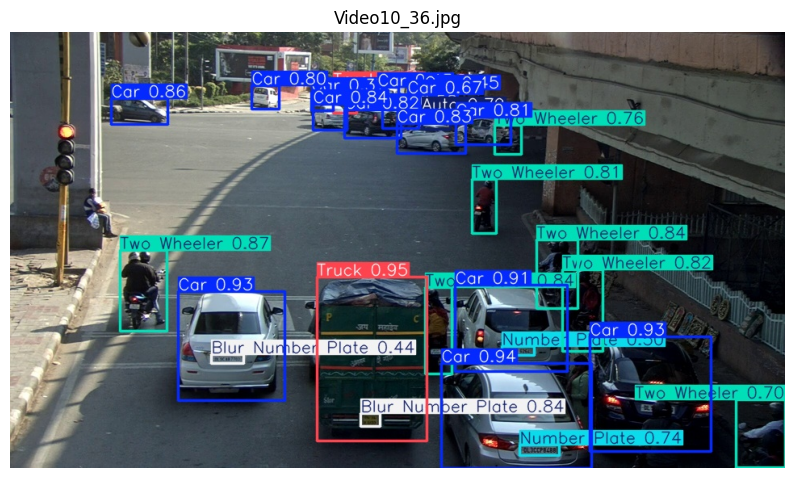

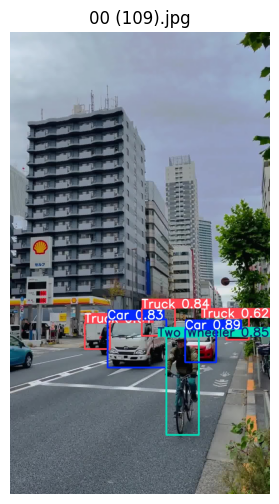

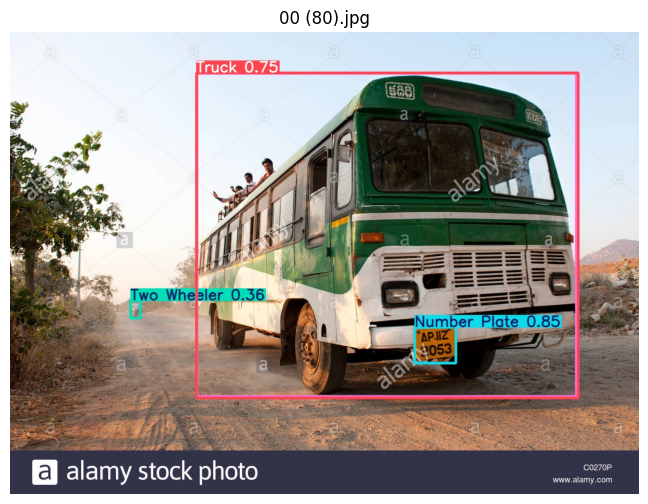

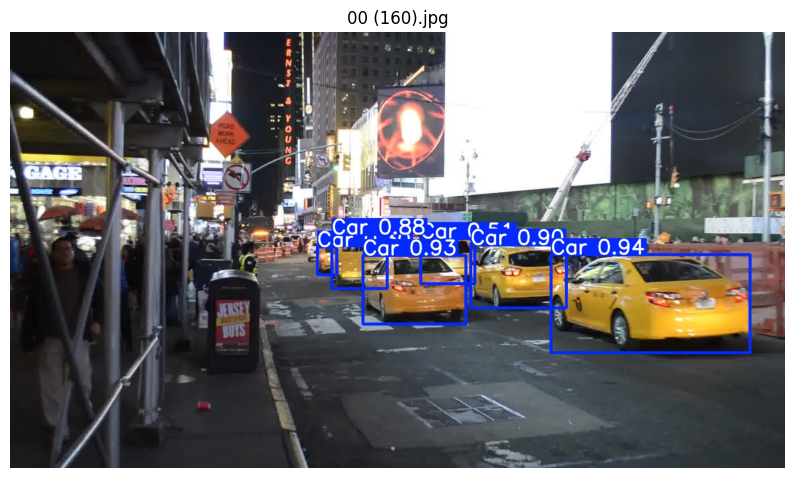

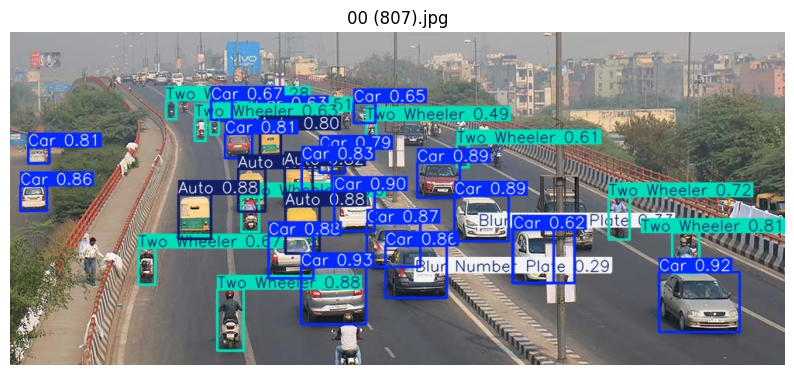

In [ ]:
# Path to the predicted images
folder_path = 'runs/predict/val_results'
# Load and display a few images
sample_files = os.listdir(folder_path)[:5]  # Show first 5 images

for file in sample_files:
    if file.endswith('.jpg') or file.endswith('.png'):
        img_path = os.path.join(folder_path, file)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(10, 6))
        plt.imshow(img)
        plt.title(file)
        plt.axis('off')
        plt.show()

# **### predict label for test data

In [ ]:
import cv2
from pathlib import Path

test_folder = Path("/kaggle/input/traffic-vehicles-object-detection/Traffic Dataset/images/test")
image_exts = ['.jpg', '.jpeg', '.png']
video_exts = ['.mp4', '.avi', '.mov', '.mkv']

image_count = 0
txt_expected = 0
frame_skip = 10

for file_path in test_folder.iterdir():
    if file_path.suffix.lower() in image_exts:
        image_count += 1
        txt_expected += 1  # one per image
    elif file_path.suffix.lower() in video_exts:
        cap = cv2.VideoCapture(str(file_path))
        frame_total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        cap.release()
        frame_processed = frame_total // frame_skip
        txt_expected += frame_processed

print(f"🖼️ Images found: {image_count}")
print(f"🎞️ Estimated .txt label files (with frame skipping): {txt_expected}")


In [ ]:

from ultralytics import YOLO
import cv2
from pathlib import Path
import shutil


# ✅ Define folders
test_folder = Path("/kaggle/input/traffic-vehicles-object-detection/Traffic Dataset/images/test")
save_dir = Path("runs/predict/test_results")
label_dir = save_dir / "labels"
image_out_dir = save_dir / "images"
video_out_dir = save_dir / "videos"

# 🧹 Clean and create output directories
shutil.rmtree(save_dir, ignore_errors=True)
label_dir.mkdir(parents=True, exist_ok=True)
image_out_dir.mkdir(parents=True, exist_ok=True)
video_out_dir.mkdir(parents=True, exist_ok=True)

# ✅ Supported extensions
image_exts = ['.jpg', '.jpeg', '.png']
video_exts = ['.mp4', '.avi', '.mov', '.mkv']
frame_skip = 3  # ⬅️ More frequent frames for smoother video

# ✅ Counters
image_count = 0
video_frame_count = 0
txt_expected = 0

# ✅ Process all files in test folder
for file_path in test_folder.iterdir():
    if file_path.suffix.lower() in image_exts:
        image_count += 1
        txt_expected += 1

        results = model.predict(
            source=str(file_path),
            conf=0.25,
            imgsz=640,
            save=False
        )

        # Save annotated image
        out_img = results[0].plot()
        image_out_path = image_out_dir / file_path.name
        cv2.imwrite(str(image_out_path), out_img)

        # Save label file
        label_path = label_dir / f"{file_path.stem}.txt"
        with open(label_path, "w") as f:
            for box in results[0].boxes:
                cls = int(box.cls[0])
                conf = float(box.conf[0])
                x, y, w, h = box.xywh[0]
                f.write(f"{cls} {x} {y} {w} {h} {conf:.4f}\n")

        del results

    elif file_path.suffix.lower() in video_exts:
        cap = cv2.VideoCapture(str(file_path))
        fps = cap.get(cv2.CAP_PROP_FPS)
        if not fps or fps == 0:
            fps = 24  # fallback FPS
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

        out_video_path = video_out_dir / f"{file_path.stem}_detected.mp4"
        out_video = None  # Lazy init

        frame_num = 0
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            frame_num += 1
            if frame_num % frame_skip != 0:
                continue

            video_frame_count += 1
            txt_expected += 1

            # Resize for model
            resized = cv2.resize(frame, (640, 640))
            results = model.predict(
                source=resized,
                conf=0.25,
                imgsz=640,
                save=False
            )

            # Plot detection (even if empty)
            plotted = results[0].plot()
            plotted_resized = cv2.resize(plotted, (width, height))

            # Initialize writer
            if out_video is None:
                out_video = cv2.VideoWriter(
                    str(out_video_path),
                    cv2.VideoWriter_fourcc(*'mp4v'),
                    fps,
                    (width, height)
                )

            out_video.write(plotted_resized)

            # Save label only if detection exists
            if len(results[0].boxes) > 0:
                label_path = label_dir / f"{file_path.stem}_frame{frame_num}.txt"
                with open(label_path, "w") as f:
                    for box in results[0].boxes:
                        cls = int(box.cls[0])
                        conf = float(box.conf[0])
                        x, y, w, h = box.xywh[0]
                        f.write(f"{cls} {x} {y} {w} {h} {conf:.4f}\n")

            del results

        cap.release()
        if out_video:
            out_video.release()

# ✅ Count actual saved .txt labels
txt_actual = len(list(label_dir.glob("*.txt")))

# ✅ Report summary
print("✅ Object Detection Completed")
print(f"🖼️  Images processed: {image_count}")
print(f"🎞️  Video frames processed: {video_frame_count} (every {frame_skip}th frame)")
print(f"📄 Expected .txt files: {txt_expected}")
print(f"📁 Actual .txt files saved: {txt_actual}")

if txt_expected == txt_actual:
    print("✅ All labels saved correctly.")
else:
    print("⚠️ Label count mismatch. Check missing or extra files.")


In [ ]:

txt_dir = 'runs/predict/test_results/labels'
txt_files = os.listdir(txt_dir)
print(f"🔍 Number of .txt prediction files: {len(txt_files)}")
